In [1]:
import torch
import matplotlib.pyplot as plt
import json
import torch.optim as optim
import torch.nn as nn
import importlib
import helpfunction
importlib.reload(helpfunction)
from helpfunction import make_plots, dataset, train, evaluate, CustomCNN
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
def f(x, y):
    return (x - 3)**2 + (y + 2)**2

def partial_derivatives(x, y):
    df_dx = 2 * (x - 3)
    df_dy = 2 * (y + 2)
    return df_dx, df_dy

def gradient_descent(x_init, y_init, learning_rate, iterations):
    x, y = x_init, y_init
    xs = []
    ys = []
    for i in range(iterations):
        df_dx, df_dy = partial_derivatives(x, y)
        x -= learning_rate * df_dx
        y -= learning_rate * df_dy
        xs.append(x)
        ys.append(y)
        # print(f"Iteration {i+1}: x={x:.4f}, y={y:.4f}, f(x,y)={f(x,y):.4f}")
    return x, y, xs, ys

x, y, xs, ys = gradient_descent(x_init=0.0, y_init=0.0, learning_rate=0.1, iterations=20)

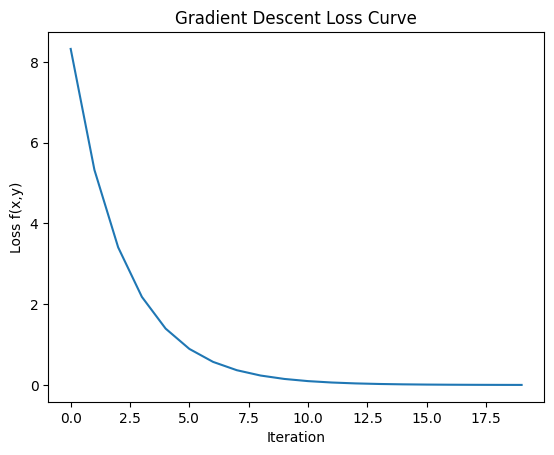

In [3]:
loss = [f(x, y) for x, y in zip(xs, ys)]

plt.figure()
plt.plot(loss)
plt.xlabel("Iteration")
plt.ylabel("Loss f(x,y)")
plt.title("Gradient Descent Loss Curve")
plt.show()

### Deep Learning for Image Classification

In [4]:
from torch.utils.data import DataLoader

train_dataset, test_dataset = dataset()

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

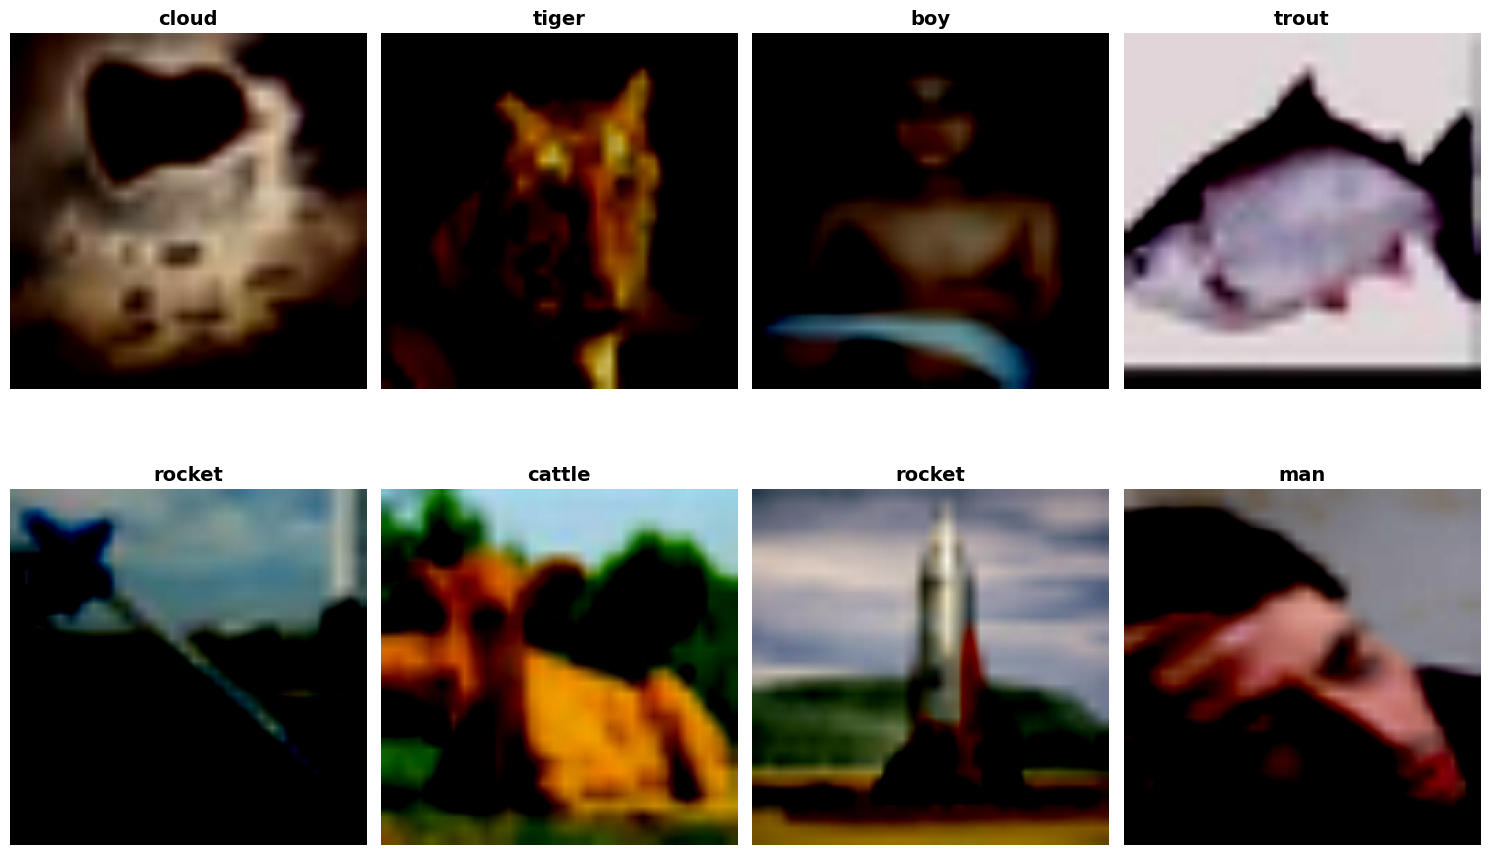

In [5]:
data, labels = next(iter(train_loader))
classes = train_dataset.classes
data = data[:8]
make_plots(classes, data, labels)

## ResNet-50 Model

In [15]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, vgg19, densenet121, efficientnet_b0

# Number of classes in your dataset
num_classes = 100

# --------- ResNet-50 ---------
resnet = resnet50(pretrained=True)
print("ResNet-50 original output classes:", resnet.fc.out_features)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)  # update output layer

# --------- VGG19 ---------
vgg = vgg19(pretrained=True)
print("VGG19 original output classes:", vgg.classifier[-1].out_features)
vgg.classifier[-1] = nn.Linear(vgg.classifier[-1].in_features, num_classes)
vgg.classifier[-1] = nn.Linear(vgg.classifier[-1].in_features, num_classes)

# -----------------------------
# Freeze all convolutional layers
for param in vgg.features.parameters():
    param.requires_grad = False
# --------- DenseNet-121 ---------

densenet = densenet121(pretrained=True)
print("DenseNet-121 original output classes:", densenet.classifier.out_features)
densenet.classifier = nn.Linear(densenet.classifier.in_features, num_classes)

# --------- EfficientNet-B0 ---------
efficientnet = efficientnet_b0(pretrained=True)
print("EfficientNet-B0 original output classes:", efficientnet.classifier[-1].out_features)
efficientnet.classifier[-1] = nn.Linear(efficientnet.classifier[-1].in_features, num_classes)

print("\nAll models updated to have", num_classes, "output classes.")

ResNet-50 original output classes: 1000
VGG19 original output classes: 1000
DenseNet-121 original output classes: 1000
EfficientNet-B0 original output classes: 1000

All models updated to have 100 output classes.


In [16]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

**The training took 68 minutes for 20 eoches in a hardware with 32 GB RAM and NVIDIA GForce RTX 5080**

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import json
import time


# Assume CustomCNN is defined
custom_model = CustomCNN().to(device)

# Pretrained models with updated final layers (from your snippet)
resnet_model = resnet.to(device)
vgg_model = vgg.to(device)
densenet_model = densenet.to(device)
efficientnet_model = efficientnet.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizers
optimizer_custom = optim.Adam(custom_model.parameters(), lr=0.001)
optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=0.001)
optimizer_vgg = optim.Adam(vgg_model.parameters(), lr=0.001)
optimizer_densenet = optim.Adam(densenet_model.parameters(), lr=0.001)
optimizer_efficientnet = optim.Adam(efficientnet_model.parameters(), lr=0.001)

# Models dictionary for easy looping
models = {
    'Custom': (custom_model, optimizer_custom),
    'ResNet50': (resnet_model, optimizer_resnet),
    'VGG19': (vgg_model, optimizer_vgg),
    'DenseNet121': (densenet_model, optimizer_densenet),
    'EfficientNetB0': (efficientnet_model, optimizer_efficientnet)
}

# Initialize metrics
metrics = {}
for name in models.keys():
    metrics[f'{name}Accuracy'] = []
    metrics[f'{name}Loss'] = []

# Training parameters
epochs = 20
start = time.time()

# Training loop
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    for name, (model, optimizer) in models.items():
        # Train
        loss = train(model, train_loader, criterion, optimizer, device)
        # Evaluate
        acc = evaluate(model, test_loader, device)
        # Store metrics
        metrics[f'{name}Accuracy'].append(acc)
        metrics[f'{name}Loss'].append(loss)
        print(f"{name} Accuracy: {acc:.2f}%, Loss: {loss:.4f}")

end = time.time()
print(f"\nTraining completed in {end - start:.2f} seconds")

# Save metrics
with open("metrics.json", "w") as f:
    json.dump(metrics, f)

# Save model weights
for name, (model, _) in models.items():
    torch.save(model.state_dict(), f"{name}_model.pth")
    print(f"Saved {name}_model.pth")


Epoch 1/20
Custom Accuracy: 11.64%, Loss: 4.1505
ResNet50 Accuracy: 39.78%, Loss: 2.8183
VGG19 Accuracy: 48.76%, Loss: 2.6681
DenseNet121 Accuracy: 60.13%, Loss: 1.8432
EfficientNetB0 Accuracy: 71.96%, Loss: 1.4121

Epoch 2/20
Custom Accuracy: 17.81%, Loss: 3.6778
ResNet50 Accuracy: 53.21%, Loss: 1.7380
VGG19 Accuracy: 50.90%, Loss: 2.2244
DenseNet121 Accuracy: 65.63%, Loss: 1.0956
EfficientNetB0 Accuracy: 74.47%, Loss: 0.8004

Epoch 3/20
Custom Accuracy: 23.21%, Loss: 3.3739
ResNet50 Accuracy: 59.15%, Loss: 1.3181
VGG19 Accuracy: 53.53%, Loss: 2.0573
DenseNet121 Accuracy: 69.16%, Loss: 0.8588
EfficientNetB0 Accuracy: 76.67%, Loss: 0.6037

Epoch 4/20
Custom Accuracy: 26.08%, Loss: 3.0785
ResNet50 Accuracy: 63.04%, Loss: 1.0498
VGG19 Accuracy: 52.91%, Loss: 1.9081
DenseNet121 Accuracy: 71.65%, Loss: 0.6823
EfficientNetB0 Accuracy: 76.59%, Loss: 0.4848

Epoch 5/20
Custom Accuracy: 28.70%, Loss: 2.8153
ResNet50 Accuracy: 64.97%, Loss: 0.8223
VGG19 Accuracy: 55.26%, Loss: 1.8333
DenseNet1

In [20]:
from PIL import Image
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate models
resnet_model = torchvision.models.resnet50(num_classes=100).to(device)

# Load weights
efficientnet = efficientnet_b0(pretrained=True)
efficientnet.classifier[-1] = nn.Linear(efficientnet.classifier[-1].in_features, num_classes)

efficientnet.load_state_dict(torch.load("EfficientNetB0_model.pth", map_location=device))


<All keys matched successfully>

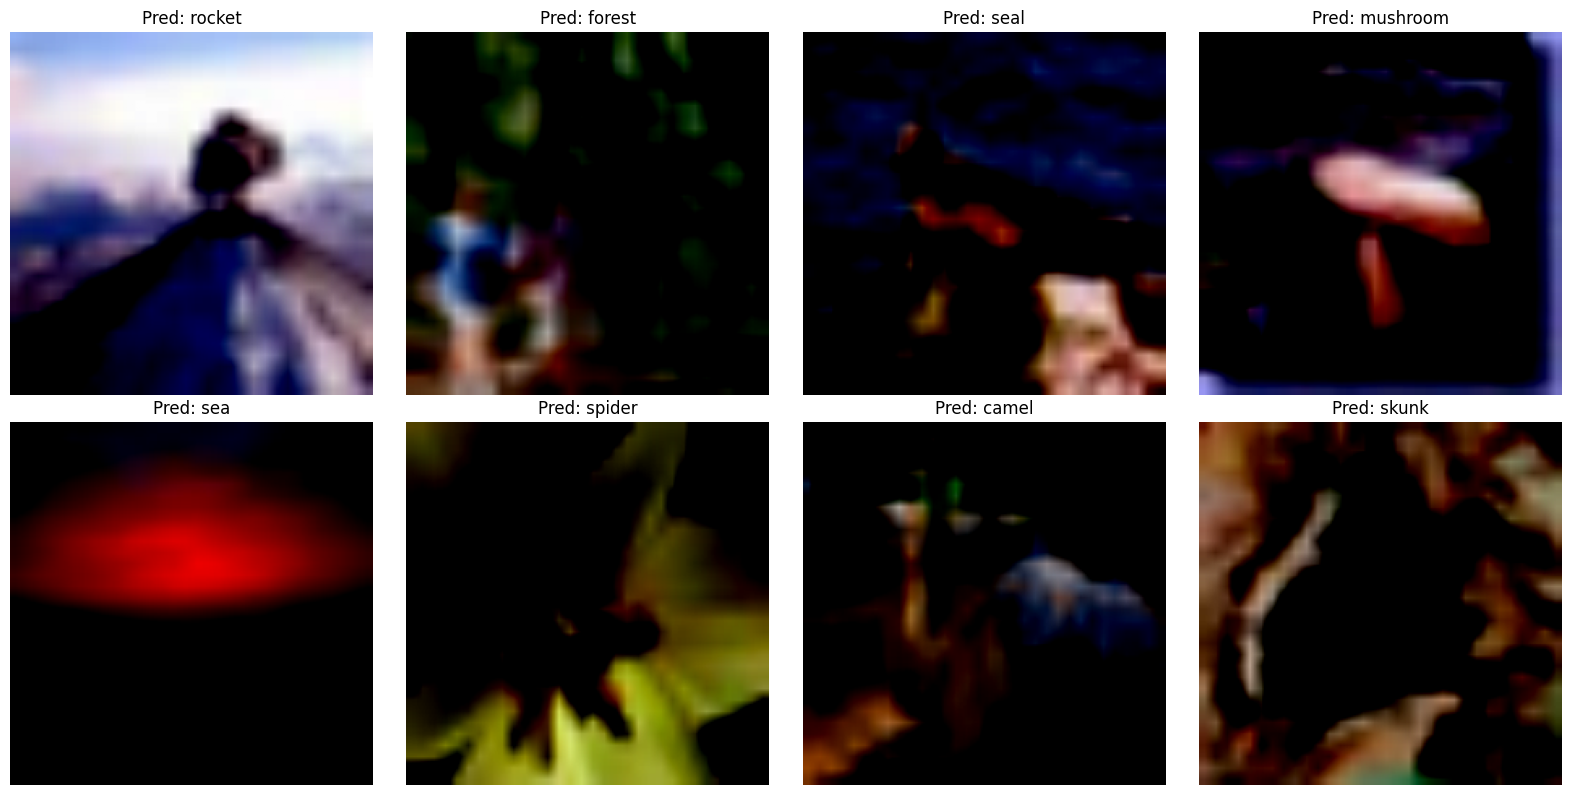

In [23]:
import torch
import matplotlib.pyplot as plt

# 1. Select the EfficientNet model from your dictionary and set to evaluation mode
efficientnet = efficientnet.to(device)
efficientnet.eval()

class_names = train_dataset.classes

images_list = []
preds_list = []

# Collect exactly 8 examples
max_examples = 8
count = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        for i in range(images.size(0)):
            if count >= max_examples:
                break
            
            # Forward pass
            image = images[i].unsqueeze(0)
            outputs = efficientnet(image)
            _, predicted = torch.max(outputs, 1)
            
            # Store values
            images_list.append(images[i].cpu())
            preds_list.append(predicted.item())
            
            count += 1
            
        if count >= max_examples:
            break


make_plots(class_names, images_list, preds_list)

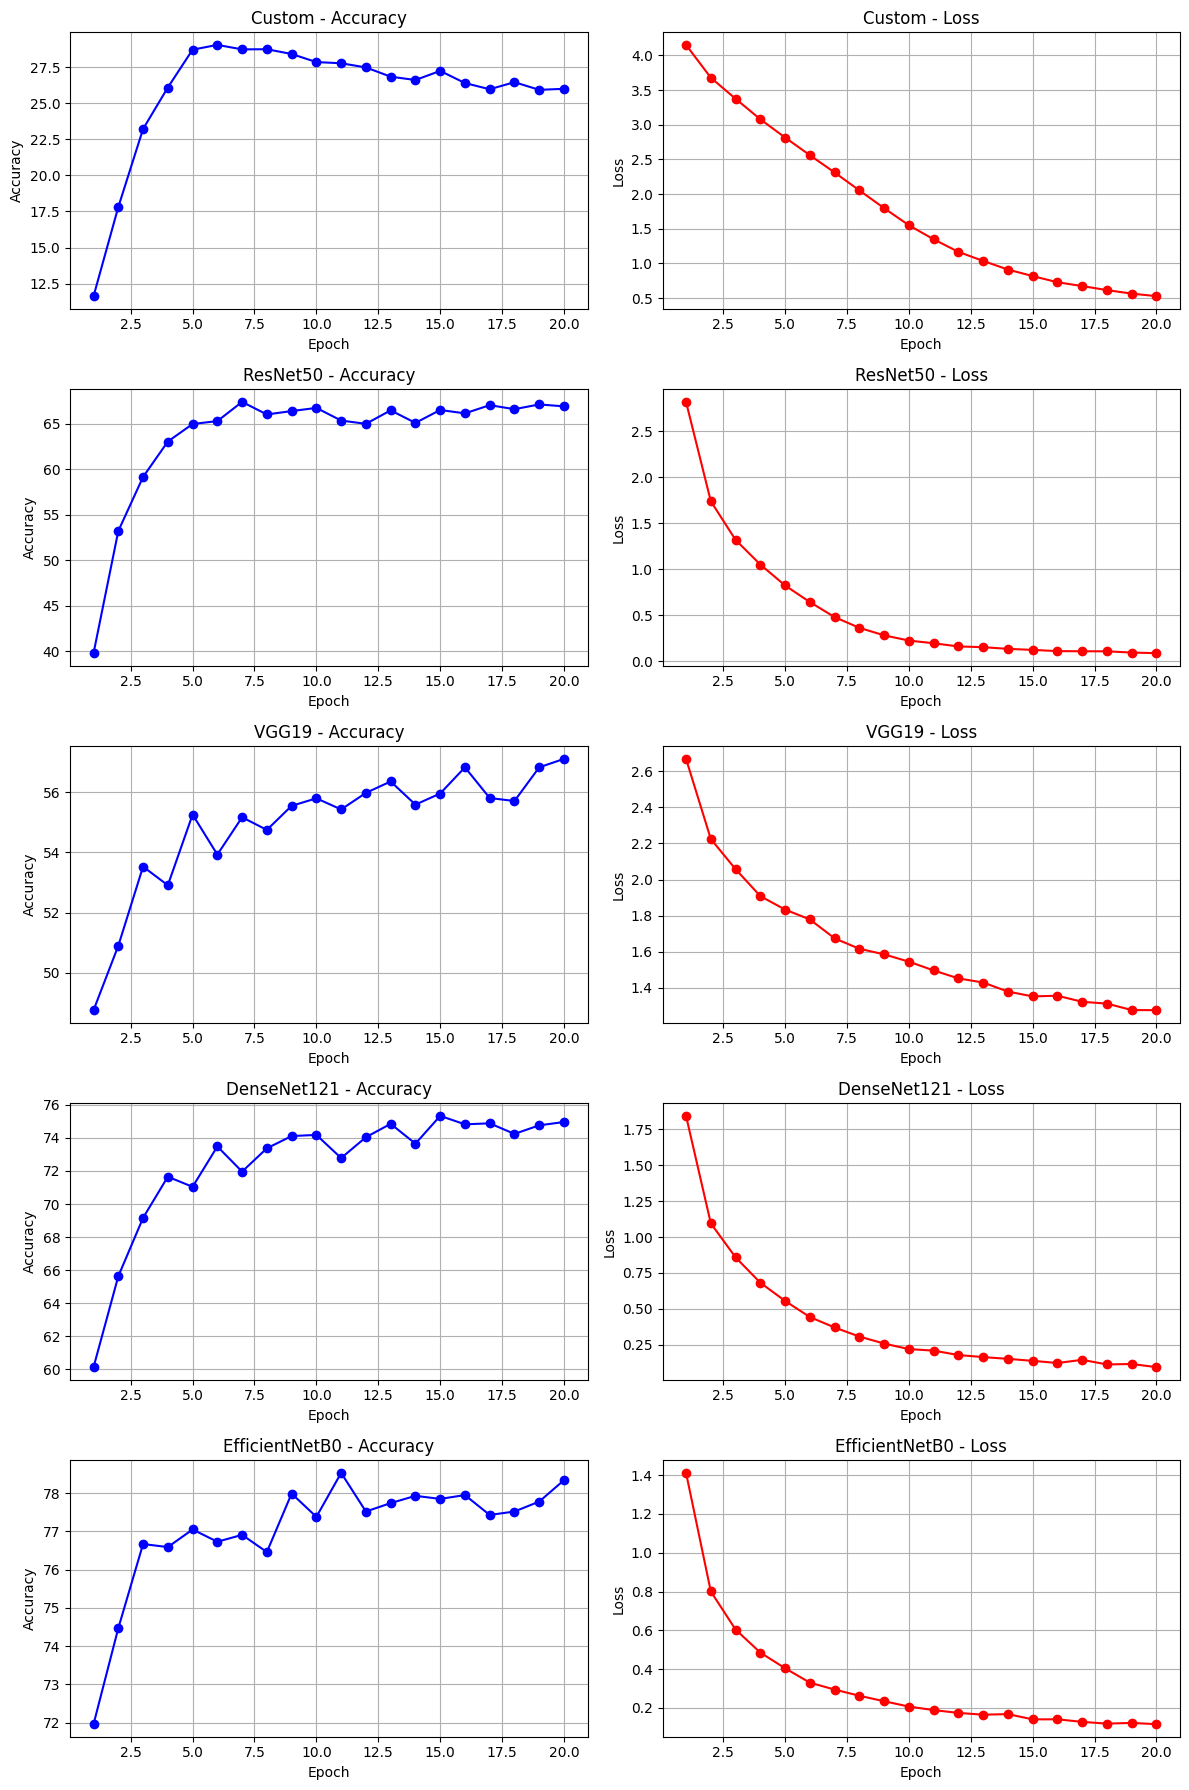

In [18]:
import json
import matplotlib.pyplot as plt

# 1. Load the metrics from the JSON file
with open("metrics.json", "r") as f:
    metrics = json.load(f)

# List of the model names
model_names = ['Custom', 'ResNet50', 'VGG19', 'DenseNet121', 'EfficientNetB0']

# 2. Create a 5x2 figure
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

# 3. Iterate through each model and plot accuracy and loss
for i, name in enumerate(model_names):
    acc_key = f"{name}Accuracy"
    loss_key = f"{name}Loss"
    epochs_range = range(1, len(metrics[acc_key]) + 1)
    
    # Plot Accuracy (Left Column)
    axes[i, 0].plot(epochs_range, metrics[acc_key], marker='o', color='b', linestyle='-')
    axes[i, 0].set_title(f'{name} - Accuracy')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Accuracy')
    axes[i, 0].grid(True)
    
    # Plot Loss (Right Column)
    axes[i, 1].plot(epochs_range, metrics[loss_key], marker='o', color='r', linestyle='-')
    axes[i, 1].set_title(f'{name} - Loss')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Loss')
    axes[i, 1].grid(True)

# Adjust layout to prevent overlap and display the plot
plt.tight_layout()
plt.show()